# EDA — YouTube Toxic Comments Dataset
**Proyecto NLP | Detección de Mensajes de Odio**  

---

## Objetivo del EDA
Antes de construir ningún modelo, necesitamos entender profundamente los datos:
- ¿Cuántos comentarios tenemos y cómo están distribuidos?
- ¿Hay desbalance de clases? (problema clásico en detección de odio)
- ¿Qué características tienen los textos? (longitud, vocabulario, patrones)
- ¿Qué insights nos orientan en el preprocesamiento y elección del modelo?

## 1. Importaciones y Configuración

In [39]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
import re
from collections import Counter
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs("../reports/figures", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

# Estilo de gráficas
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = {'toxic': '#E74C3C', 'non_toxic': '#2ECC71', 'neutral': '#3498DB'}
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 2. Carga del Dataset

In [10]:
BASE_DIR = Path().resolve().parent

DATA_PATH = BASE_DIR / 'data' / 'raw' / 'youtoxic_english_1000.csv'

df = pd.read_csv(DATA_PATH) 

print(f'📐 Shape del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'\n📋 Columnas:')
for col in df.columns:
    print(f'  - {col} ({df[col].dtype})')

📐 Shape del dataset: 1,000 filas × 15 columnas

📋 Columnas:
  - CommentId (object)
  - VideoId (object)
  - Text (object)
  - IsToxic (bool)
  - IsAbusive (bool)
  - IsThreat (bool)
  - IsProvocative (bool)
  - IsObscene (bool)
  - IsHatespeech (bool)
  - IsRacist (bool)
  - IsNationalist (bool)
  - IsSexist (bool)
  - IsHomophobic (bool)
  - IsReligiousHate (bool)
  - IsRadicalism (bool)


In [11]:
# Vista rápida del dataset
df.head(5)

,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do...,False,False,False,False,False,False,False,False,False,False,False,False
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,False,False,False,False,False,False,False


### 🔍 Estructura del Dataset

| Columna | Tipo | Descripción |
|---|---|---|
| `CommentId` | str | ID único del comentario |
| `VideoId` | str | ID del vídeo de YouTube |
| `Text` | str | **Texto del comentario** (variable principal) |
| `IsToxic` | bool | **Etiqueta principal**: tóxico o no |
| `IsAbusive` | bool | Contiene lenguaje abusivo |
| `IsThreat` | bool | Contiene amenazas |
| `IsProvocative` | bool | Contenido provocativo |
| `IsObscene` | bool | Lenguaje obsceno |
| `IsHatespeech` | bool | Discurso de odio |
| `IsRacist` | bool | Contenido racista |
| `IsNationalist` | bool | Contenido nacionalista |
| `IsSexist` | bool | Contenido sexista |
| `IsHomophobic` | bool | Contenido homofóbico |
| `IsReligiousHate` | bool | Odio religioso |
| `IsRadicalism` | bool | Radicalismo |

## 3. 🧹 Calidad de los Datos

In [12]:
print('=== 📊 Información General ===')
df.info()

print('\n=== ❌ Valores Nulos ===')
nulls = df.isnull().sum()
print(nulls)
print(f'\n✅ Valores nulos totales: {nulls.sum()}')

=== 📊 Información General ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CommentId        1000 non-null   object
 1   VideoId          1000 non-null   object
 2   Text             1000 non-null   object
 3   IsToxic          1000 non-null   bool  
 4   IsAbusive        1000 non-null   bool  
 5   IsThreat         1000 non-null   bool  
 6   IsProvocative    1000 non-null   bool  
 7   IsObscene        1000 non-null   bool  
 8   IsHatespeech     1000 non-null   bool  
 9   IsRacist         1000 non-null   bool  
 10  IsNationalist    1000 non-null   bool  
 11  IsSexist         1000 non-null   bool  
 12  IsHomophobic     1000 non-null   bool  
 13  IsReligiousHate  1000 non-null   bool  
 14  IsRadicalism     1000 non-null   bool  
dtypes: bool(12), object(3)
memory usage: 35.3+ KB

=== ❌ Valores Nulos ===
CommentId          0
Vi

In [13]:
# Duplicados
n_dup = df.duplicated(subset='Text').sum()
print(f'🔁 Comentarios duplicados detectados: {n_dup}')

if n_dup > 0:
    df = df.drop_duplicates(subset='Text', keep='first').reset_index(drop=True)
    print(f'✅ Duplicados eliminados. Nuevo shape: {df.shape}')
else:
    print('✅ No hay duplicados.')

# VideoIds únicos
print(f'\n🎬 Vídeos únicos en el dataset: {df["VideoId"].nunique()}')
print(df['VideoId'].value_counts().to_frame('comentarios').rename_axis('VideoId'))

# Detectar entradas problemáticas en VideoId
problematic = df[df['VideoId'].str.startswith('#', na=False)]
print(f'\n⚠️  Filas con VideoId problemático (#NAME? de Excel): {len(problematic)}')


🔁 Comentarios duplicados detectados: 3
✅ Duplicados eliminados. Nuevo shape: (997, 15)

🎬 Vídeos únicos en el dataset: 13
             comentarios
VideoId                 
9pr1oE34bIM          274
04kJtp6pVXI          172
cT14IbTDW2c          143
dG7mZQvaQDk          112
TZxEyoplYbI          104
bUgKZMSxr3E           39
8HB18hZrhXc           38
4rCweDxDqdw           37
Dt9-byUhPdg           34
#NAME?                16
dDbRyFIkNII           10
XRuCW80L9mA           10
5vF4si3hoRA            8

⚠️  Filas con VideoId problemático (#NAME? de Excel): 16


## 4. Distribución de Clases (Balance del Dataset)

In [14]:
# --- Distribución IsToxic ---
toxic_counts = df['IsToxic'].value_counts()
toxic_pct = df['IsToxic'].value_counts(normalize=True) * 100

print('=== 🏷️ Distribución IsToxic ===')
for val in [True, False]:
    label = '🔴 Tóxico   ' if val else '🟢 No tóxico'
    print(f'  {label}: {toxic_counts[val]:>4} comentarios ({toxic_pct[val]:.1f}%)')

ratio = toxic_counts[True] / toxic_counts[False]
print(f'\n📐 Ratio tóxico/no-tóxico: {ratio:.2f}')
print(f'→ Dataset relativamente balanceado ({toxic_pct[True]:.1f}% vs {toxic_pct[False]:.1f}%)')
print('  Pero se recomienda vigilar las métricas F1 y no solo Accuracy.')

=== 🏷️ Distribución IsToxic ===
  🔴 Tóxico   :  459 comentarios (46.0%)
  🟢 No tóxico:  538 comentarios (54.0%)

📐 Ratio tóxico/no-tóxico: 0.85
→ Dataset relativamente balanceado (46.0% vs 54.0%)
  Pero se recomienda vigilar las métricas F1 y no solo Accuracy.


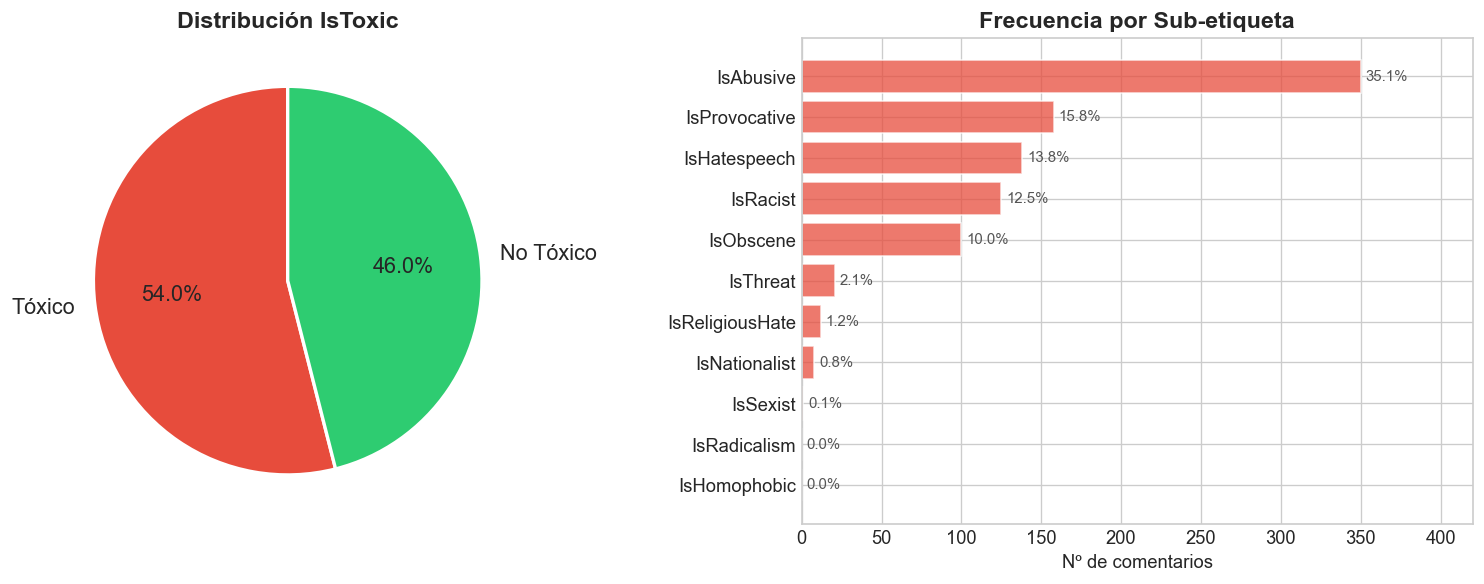

💾 Guardado: fig01_class_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Pie chart ---
colors = [PALETTE['toxic'], PALETTE['non_toxic']]
axes[0].pie(
    toxic_counts.values,
    labels=['Tóxico', 'No Tóxico'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 13}
)
axes[0].set_title('Distribución IsToxic', fontweight='bold', fontsize=14)

# --- Barras de sub-etiquetas ---
label_cols = [
    'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene',
    'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist',
    'IsHomophobic', 'IsReligiousHate', 'IsRadicalism'
]
label_counts = df[label_cols].sum().sort_values(ascending=True)
label_pct = (label_counts / len(df) * 100)

bars = axes[1].barh(
    label_counts.index,
    label_counts.values,
    color=PALETTE['toxic'],
    alpha=0.75,
    edgecolor='white'
)
# Añadir porcentaje
for bar, pct in zip(bars, label_pct.values):
    axes[1].text(
        bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
        f'{pct:.1f}%', va='center', fontsize=9, color='#555'
    )
axes[1].set_title('Frecuencia por Sub-etiqueta', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Nº de comentarios')
axes[1].set_xlim(0, label_counts.max() * 1.2)

plt.tight_layout()
plt.savefig('../reports/figures/fig01_class_distribution.png', bbox_inches='tight')
plt.show()
print('💾 Guardado: fig01_class_distribution.png')

### 💡 Insights — Distribución de clases
- El dataset está **casi balanceado** (46.0% tóxico vs 54.0% no tóxico, ratio 0.85) → no se necesita oversampling agresivo. Como precaución, usar `class_weight="balanced"` en el modelo.
- **`IsAbusive`** es la sub-etiqueta más frecuente (35.1%), seguida de `IsProvocative` (15.8%) e `IsHatespeech` (13.8%).
- **`IsHomophobic`** y **`IsRadicalism`** tienen **0 casos** → se eliminarán en el preprocesamiento (columnas sin información útil).
- **`IsSexist`** tiene solo **1 caso** (0.1%) → prácticamente inútil como etiqueta individual, se descarta para modelado multi-etiqueta.
- Para clasificación **multi-etiqueta** solo tiene sentido modelar las 5 primeras sub-etiquetas (Abusive, Provocative, Hatespeech, Racist, Obscene).

## 5. Análisis de Longitud de Textos

In [16]:
# Feature engineering básico de longitud
df['char_count']  = df['Text'].str.len()
df['word_count']  = df['Text'].str.split().str.len()
df['sent_count']  = df['Text'].str.count(r'[.!?]+')
df['avg_word_len'] = df['char_count'] / df['word_count']

print('=== 📊 Estadísticas de longitud ===')
stats = df[['char_count', 'word_count', 'sent_count']].describe().round(1)
print(stats)

print('\n⚠️ Comentarios muy cortos (<= 5 palabras):')
short = df[df['word_count'] <= 5][['Text', 'IsToxic', 'word_count']].head(8)
print(short.to_string(index=False))

print('\n⚠️ Comentario más largo (palabras):')
longest = df.loc[df['word_count'].idxmax()]
print(f'  {longest["word_count"]} palabras | Tóxico: {longest["IsToxic"]}')
print(f'  Texto: {longest["Text"][:200]}...')

=== 📊 Estadísticas de longitud ===
       char_count  word_count  sent_count
count       997.0       997.0       997.0
mean        186.1        33.9         2.4
std         271.0        49.1         3.4
min           3.0         1.0         0.0
25%          47.0         9.0         1.0
50%         102.0        19.0         1.0
75%         217.0        39.0         3.0
max        4421.0       815.0        59.0

⚠️ Comentarios muy cortos (<= 5 palabras):
                       Text  IsToxic  word_count
I agree with the protestor.    False           5
       I think ,he kill him     True           5
1 word: Provocateur........    False           3
            I LIKE TURTLES!    False           3
 Massri needs an education.     True           4
      CNN is such Bullcrap!     True           4
  5:09 plain n simple truth    False           5
      Iz didn't do nuffinz!    False           4

⚠️ Comentario más largo (palabras):
  815 palabras | Tóxico: True
  Texto: THE UGLY TRUTH:

If you ta

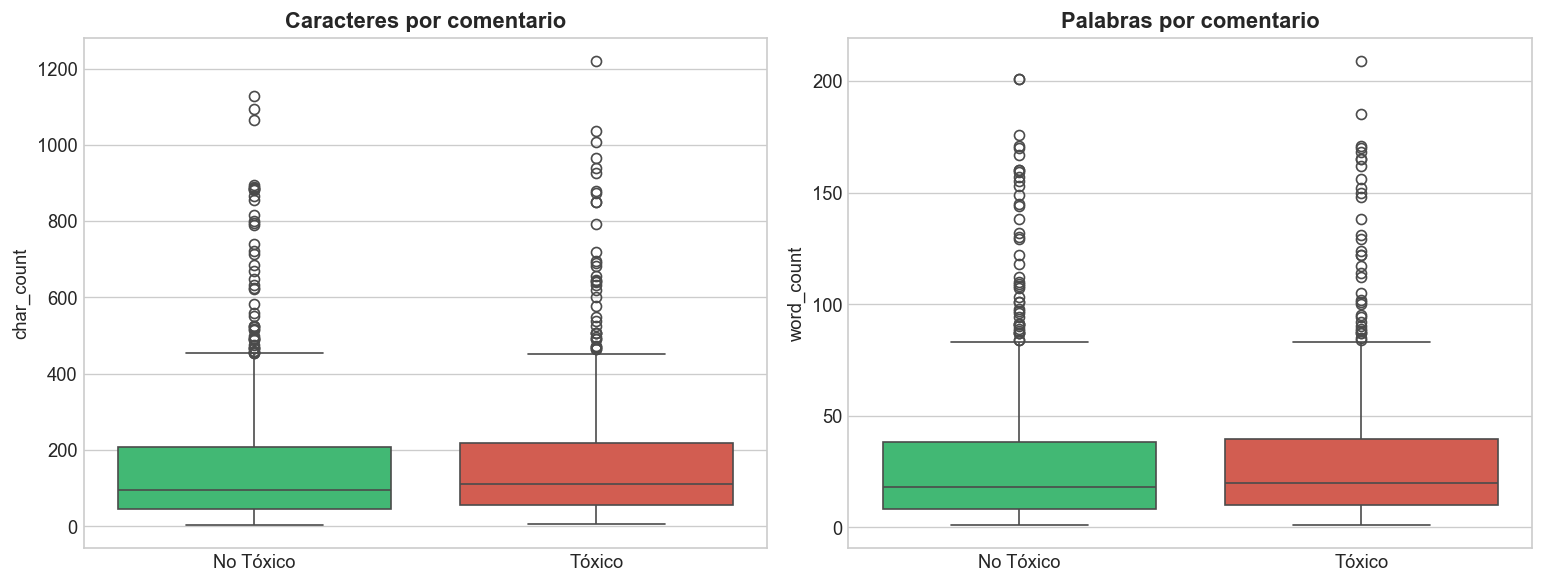

💾 Guardado: fig03_length_boxplot.png


In [ ]:
# Boxplot por clase
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in zip(
    axes,
    ['char_count', 'word_count'],
    ['Caracteres por comentario', 'Palabras por comentario']
):
    df_plot = df[df[col] <= df[col].quantile(0.99)].copy()
    # Convertir booleano a string para evitar error de seaborn con palette dict
    df_plot['IsToxic_str'] = df_plot['IsToxic'].map({True: 'Tóxico', False: 'No Tóxico'})
    sns.boxplot(
        data=df_plot, x='IsToxic_str', y=col, ax=ax,
        order=['No Tóxico', 'Tóxico'],
        palette={'Tóxico': PALETTE['toxic'], 'No Tóxico': PALETTE['non_toxic']}
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('../reports/figures/fig03_length_boxplot.png', bbox_inches='tight')
plt.show()
print('💾 Guardado: fig03_length_boxplot.png')


In [21]:
# Media de longitud por clase
print('=== 📊 Longitud media por clase ===')
summary = df.groupby('IsToxic')[['char_count', 'word_count']].mean().round(1)
summary.index = ['No Tóxico', 'Tóxico']
print(summary)

=== 📊 Longitud media por clase ===
           char_count  word_count
No Tóxico       182.3        33.1
Tóxico          190.5        34.8


### 💡 Insights — Longitud de textos
- **Alta variabilidad**: desde 1 palabra hasta 815. Mediana **19 palabras / 102 caracteres**, media **34 palabras / 186 caracteres** → distribución muy sesgada a la derecha.
- **La longitud NO es un buen predictor de toxicidad**: la diferencia entre clases es mínima (190 vs 182 chars, 34.8 vs 33.1 palabras). El modelo deberá aprender del contenido semántico, no de la longitud.
- Los boxplots muestran IQR casi idéntico entre ambas clases, con outliers abundantes y similares en ambas → la distribución de longitud es independiente de la etiqueta.
- El comentario más largo (815 palabras, tóxico) es un monólogo de odio estructurado escrito en MAYÚSCULAS — outlier extremo que distorsiona la media.
- **Para TF-IDF**: no hay que truncar, maneja cualquier longitud. **Para LSTM/Transformers**: fijar `max_len=200` (cubre el percentil 95+).
- Comentarios de 1-3 palabras pueden ser ruido puro → considerar filtro mínimo en producción.

## 6. Análisis de Vocabulario y Texto

In [22]:
# URLs, menciones, mayúsculas
df['has_url']      = df['Text'].str.contains(r'http[s]?://|www\.', regex=True, case=False)
df['has_mention']  = df['Text'].str.contains(r'@\w+', regex=True)
df['n_exclamation']= df['Text'].str.count('!')
df['n_question']   = df['Text'].str.count('\?')
df['pct_uppercase'] = df['Text'].apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1) * 100
)

print('=== 🔍 Características textuales ===')
features = ['has_url', 'has_mention']
for f in features:
    toxic_pct  = df[df['IsToxic'] == True][f].mean() * 100
    ntoxic_pct = df[df['IsToxic'] == False][f].mean() * 100
    print(f'  {f:<20}: Tóxico {toxic_pct:.1f}%  |  No Tóxico {ntoxic_pct:.1f}%')

print('\n=== 🔡 % de mayúsculas por clase ===')
print(df.groupby('IsToxic')['pct_uppercase'].mean().round(2))

=== 🔍 Características textuales ===
  has_url             : Tóxico 0.2%  |  No Tóxico 2.0%
  has_mention         : Tóxico 0.7%  |  No Tóxico 0.4%

=== 🔡 % de mayúsculas por clase ===
IsToxic
False    5.00
True     5.46
Name: pct_uppercase, dtype: float64


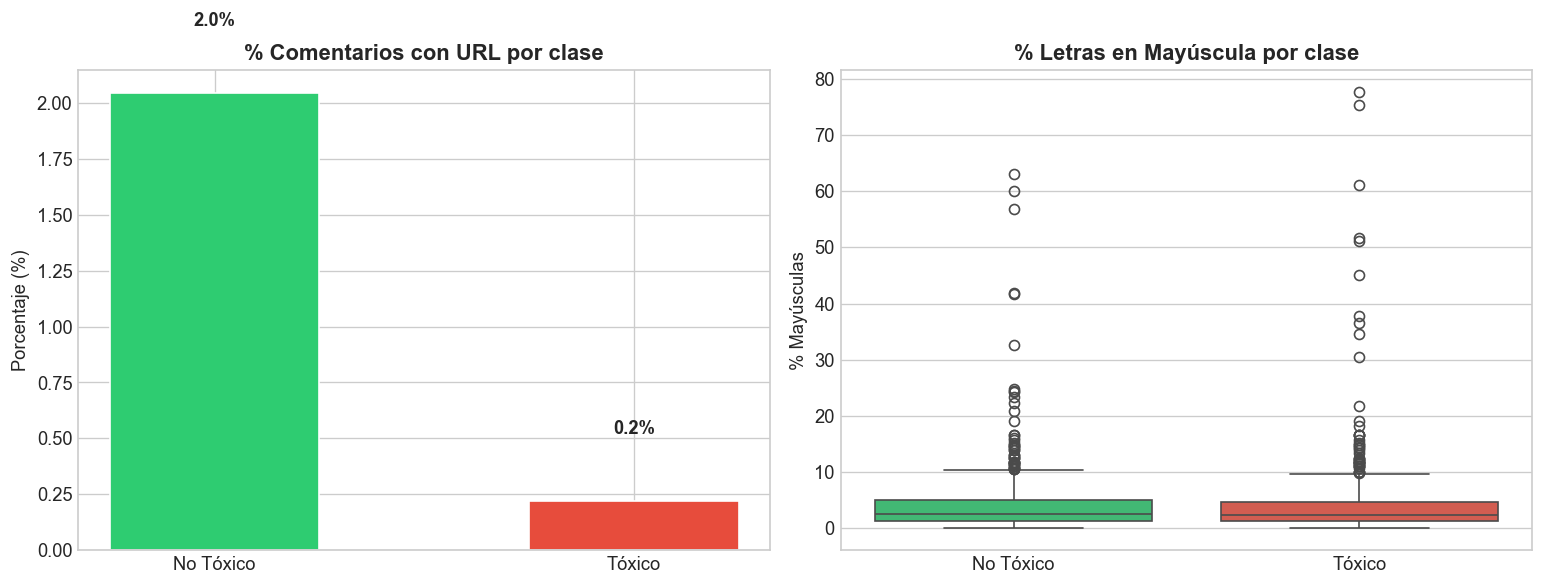

💾 Guardado: fig04_text_features.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# % URLs por clase
url_data = df.groupby('IsToxic')['has_url'].mean() * 100
url_data.index = ['No Tóxico', 'Tóxico']
axes[0].bar(url_data.index, url_data.values,
            color=[PALETTE['non_toxic'], PALETTE['toxic']], edgecolor='white', width=0.5)
axes[0].set_title('% Comentarios con URL por clase', fontweight='bold')
axes[0].set_ylabel('Porcentaje (%)')
for i, v in enumerate(url_data.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# % Mayúsculas por clase — convertir bool a string para evitar error de seaborn
df_upper = df[df['pct_uppercase'] <= df['pct_uppercase'].quantile(0.99)].copy()
df_upper['IsToxic_str'] = df_upper['IsToxic'].map({True: 'Tóxico', False: 'No Tóxico'})
sns.boxplot(
    data=df_upper, x='IsToxic_str', y='pct_uppercase', ax=axes[1],
    order=['No Tóxico', 'Tóxico'],
    palette={'Tóxico': PALETTE['toxic'], 'No Tóxico': PALETTE['non_toxic']}
)
axes[1].set_title('% Letras en Mayúscula por clase', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('% Mayúsculas')

plt.tight_layout()
plt.savefig('../reports/figures/fig04_text_features.png', bbox_inches='tight')
plt.show()
print('💾 Guardado: fig04_text_features.png')


### 💡 Insights — Características Textuales
- **URLs**: los comentarios NO tóxicos tienen 10x más URLs (2.0% vs 0.2%) → los textos argumentativos y reflexivos citan fuentes; el odio directo no necesita referencias. Eliminar URLs en preprocesamiento es correcto.
- **Mayúsculas**: diferencia mínima entre clases (5.46% tóxicos vs 5.00% no tóxicos, solo 0.46 puntos). Los outliers extremos (~75-80%) son casos aislados tipo "THUG".
- **Conclusión clave**: ni longitud, ni URLs, ni mayúsculas discriminan bien la toxicidad. **El modelo depende casi exclusivamente del vocabulario** → refuerza TF-IDF con buen preprocesamiento como estrategia central.

## 7. Palabras Más Frecuentes (con y sin stopwords)

In [26]:
STOPWORDS = set(stopwords.words('english'))

def tokenize_basic(text):
    """Tokenización simple: minúsculas, solo letras, sin stopwords."""
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)  # quitar URLs
    tokens = re.findall(r'\b[a-z]{2,}\b', text)
    return [t for t in tokens if t not in STOPWORDS]

# Separar corpus por clase
toxic_texts    = df[df['IsToxic'] == True]['Text'].tolist()
nontoxic_texts = df[df['IsToxic'] == False]['Text'].tolist()

toxic_tokens    = [tok for text in toxic_texts for tok in tokenize_basic(text)]
nontoxic_tokens = [tok for text in nontoxic_texts for tok in tokenize_basic(text)]

toxic_freq    = Counter(toxic_tokens).most_common(20)
nontoxic_freq = Counter(nontoxic_tokens).most_common(20)

print(f'Vocabulario único (tóxicos):     {len(set(toxic_tokens)):,} palabras')
print(f'Vocabulario único (no tóxicos):  {len(set(nontoxic_tokens)):,} palabras')

Vocabulario único (tóxicos):     2,748 palabras
Vocabulario único (no tóxicos):  2,871 palabras


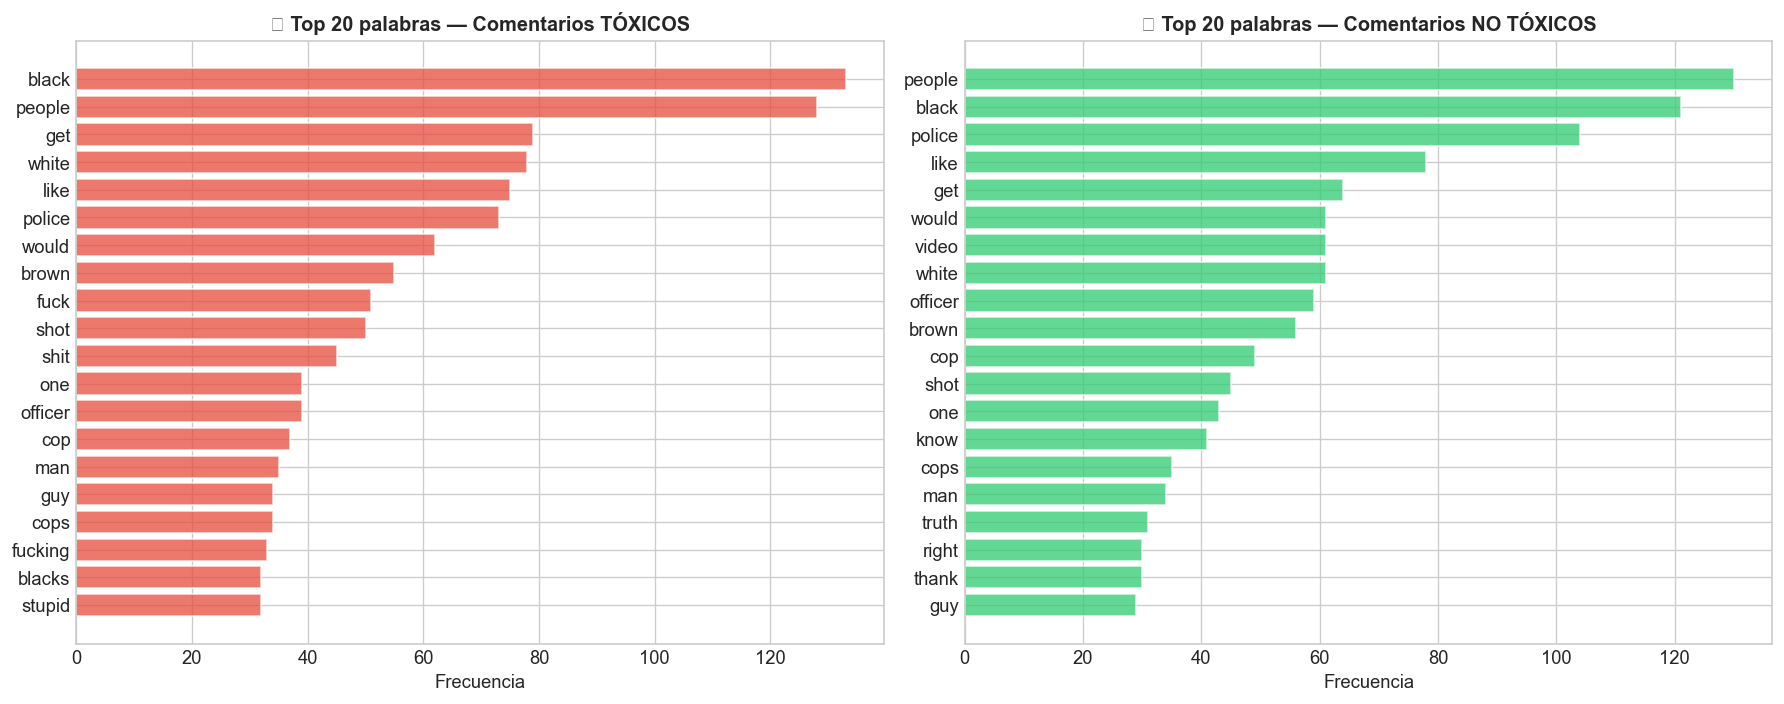

💾 Guardado: fig05_top_words.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, freq_data, title, color in [
    (axes[0], toxic_freq,    '🔴 Top 20 palabras — Comentarios TÓXICOS',    PALETTE['toxic']),
    (axes[1], nontoxic_freq, '🟢 Top 20 palabras — Comentarios NO TÓXICOS', PALETTE['non_toxic'])
]:
    words, counts = zip(*freq_data)
    y_pos = range(len(words))
    ax.barh(y_pos, counts, color=color, alpha=0.75, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words)
    ax.invert_yaxis()
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Frecuencia')

plt.tight_layout()
plt.savefig('../reports/figures/fig05_top_words.png', bbox_inches='tight')
plt.show()
print('💾 Guardado: fig05_top_words.png')

In [28]:
# Palabras diferenciales: aparecen más en tóxicos que en no-tóxicos
toxic_counter    = Counter(toxic_tokens)
nontoxic_counter = Counter(nontoxic_tokens)
all_words = set(toxic_counter.keys()) | set(nontoxic_counter.keys())

# Ratio: freq_toxic / (freq_nontoxic + 1) para evitar división por 0
diff_words = {
    w: toxic_counter.get(w, 0) / (nontoxic_counter.get(w, 0) + 1)
    for w in all_words
    if toxic_counter.get(w, 0) >= 5  # mínimo 5 ocurrencias
}

top_diff = sorted(diff_words.items(), key=lambda x: x[1], reverse=True)[:15]

print('=== 🎯 Palabras MÁS asociadas a comentarios TÓXICOS ===')
for word, ratio in top_diff:
    print(f'  {word:<20} ratio: {ratio:.2f}x más frecuente en tóxicos')

=== 🎯 Palabras MÁS asociadas a comentarios TÓXICOS ===
  idiot                ratio: 16.00x más frecuente en tóxicos
  bitch                ratio: 14.00x más frecuente en tóxicos
  fuck                 ratio: 10.20x más frecuente en tóxicos
  fucks                ratio: 9.00x más frecuente en tóxicos
  ass                  ratio: 8.33x más frecuente en tóxicos
  fucking              ratio: 8.25x más frecuente en tóxicos
  bullshit             ratio: 8.00x más frecuente en tóxicos
  drivers              ratio: 8.00x más frecuente en tóxicos
  asses                ratio: 8.00x más frecuente en tóxicos
  shit                 ratio: 7.50x más frecuente en tóxicos
  dumb                 ratio: 7.00x más frecuente en tóxicos
  isis                 ratio: 7.00x más frecuente en tóxicos
  cunts                ratio: 7.00x más frecuente en tóxicos
  racists              ratio: 7.00x más frecuente en tóxicos
  lets                 ratio: 6.00x más frecuente en tóxicos


### 💡 Insights — Vocabulario y Palabras Frecuentes
- **Contexto temático compartido**: palabras como `black`, `people`, `police`, `brown`, `shot` aparecen en el top de AMBAS clases → el dataset habla de los mismos eventos (Ferguson, Mike Brown). El modelo no puede distinguir toxicidad por estas palabras solas, necesita contexto completo.
- **Exclusivas de tóxicos**: `fuck`, `shit`, `fucking`, `blacks`, `stupid` → lenguaje abusivo directo.
- **Exclusivas de no tóxicos**: `video`, `know`, `truth`, `right`, `thank` → vocabulario argumentativo y reflexivo.
- **Palabras diferenciales top**: `idiot` (16x), `bitch` (14x), `fuck` (10x), `isis` (7x), `racists` (7x) → señal muy fuerte para el modelo TF-IDF.
- **Vocabulario único**: tóxicos 2,748 palabras vs no tóxicos 2,871 → los tóxicos usan vocabulario más repetitivo; los no tóxicos tienen mayor variedad léxica.
- **Implicación**: el TF-IDF capturará bien las palabras diferenciales. Las palabras de contexto compartido (`black`, `police`) necesitarán el peso TF para no distorsionar el modelo.

## 8. ☁️ WordCloud — Nube de Palabras

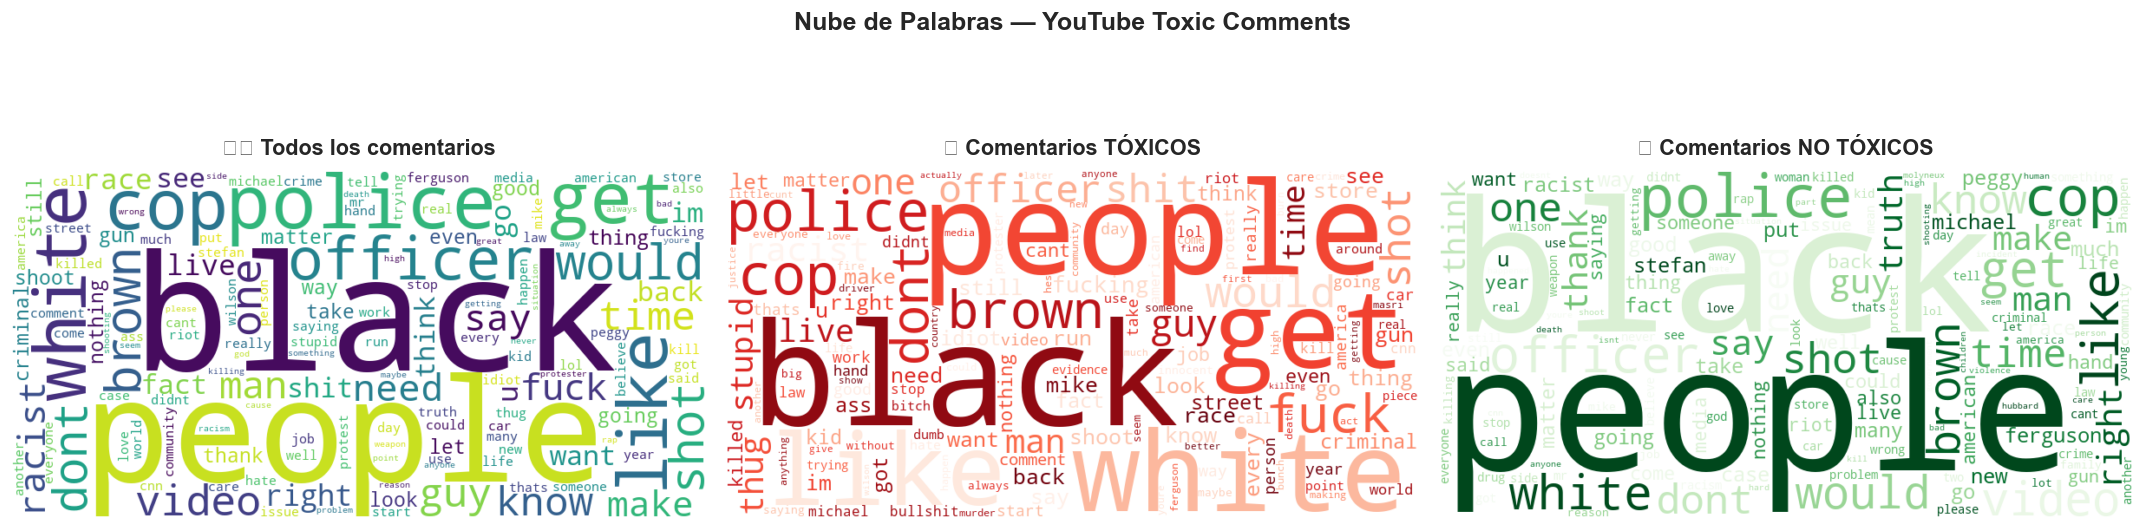

💾 Guardado: fig_wordcloud.png


In [ ]:
def clean_for_wordcloud(texts):
    combined = ' '.join(texts).lower()
    combined = re.sub(r'https?://\S+|www\.\S+', '', combined)  # quitar URLs
    combined = re.sub(r'[^a-z\s]', '', combined)               # solo letras
    return combined

all_text      = clean_for_wordcloud(df['Text'].tolist())
toxic_text    = clean_for_wordcloud(df[df['IsToxic'] == True]['Text'].tolist())
nontoxic_text = clean_for_wordcloud(df[df['IsToxic'] == False]['Text'].tolist())

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOPWORDS_WC = set(stopwords.words('english'))

wc_params = dict(
    width=800, height=400,
    stopwords=STOPWORDS_WC,
    background_color='white',
    max_words=150,
    collocations=False
)

wc_all     = WordCloud(**wc_params).generate(all_text)
wc_toxic   = WordCloud(**wc_params, colormap='Reds').generate(toxic_text)
wc_ntoxic  = WordCloud(**wc_params, colormap='Greens').generate(nontoxic_text)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, wc, title in [
    (axes[0], wc_all,    '☁️ Todos los comentarios'),
    (axes[1], wc_toxic,  '🔴 Comentarios TÓXICOS'),
    (axes[2], wc_ntoxic, '🟢 Comentarios NO TÓXICOS')
]:
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontweight='bold', fontsize=13, pad=10)

plt.suptitle('Nube de Palabras — YouTube Toxic Comments', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/fig_wordcloud.png', bbox_inches='tight', dpi=150)
plt.show()
print('💾 Guardado: fig_wordcloud.png')

### 💡 Insights — WordCloud
- Las tres nubes comparten un núcleo temático idéntico (`black`, `people`, `police`, `brown`) — el dataset gira en torno a los mismos eventos (caso Ferguson, Mike Brown). Lo que diferencia a los tóxicos es la presencia prominente de `fuck`, `shit`, `stupid`, `ass`, `bitch` y `thug` junto a términos raciales como `white`/`black` usados de forma confrontacional. Los no tóxicos en cambio destacan palabras como `truth`, `video`, `know`, `thank` y `fact` — vocabulario de debate y argumentación. El odio no cambia el tema, cambia el registro.

## 9. 🔗 Correlación de Etiquetas (Heatmap)

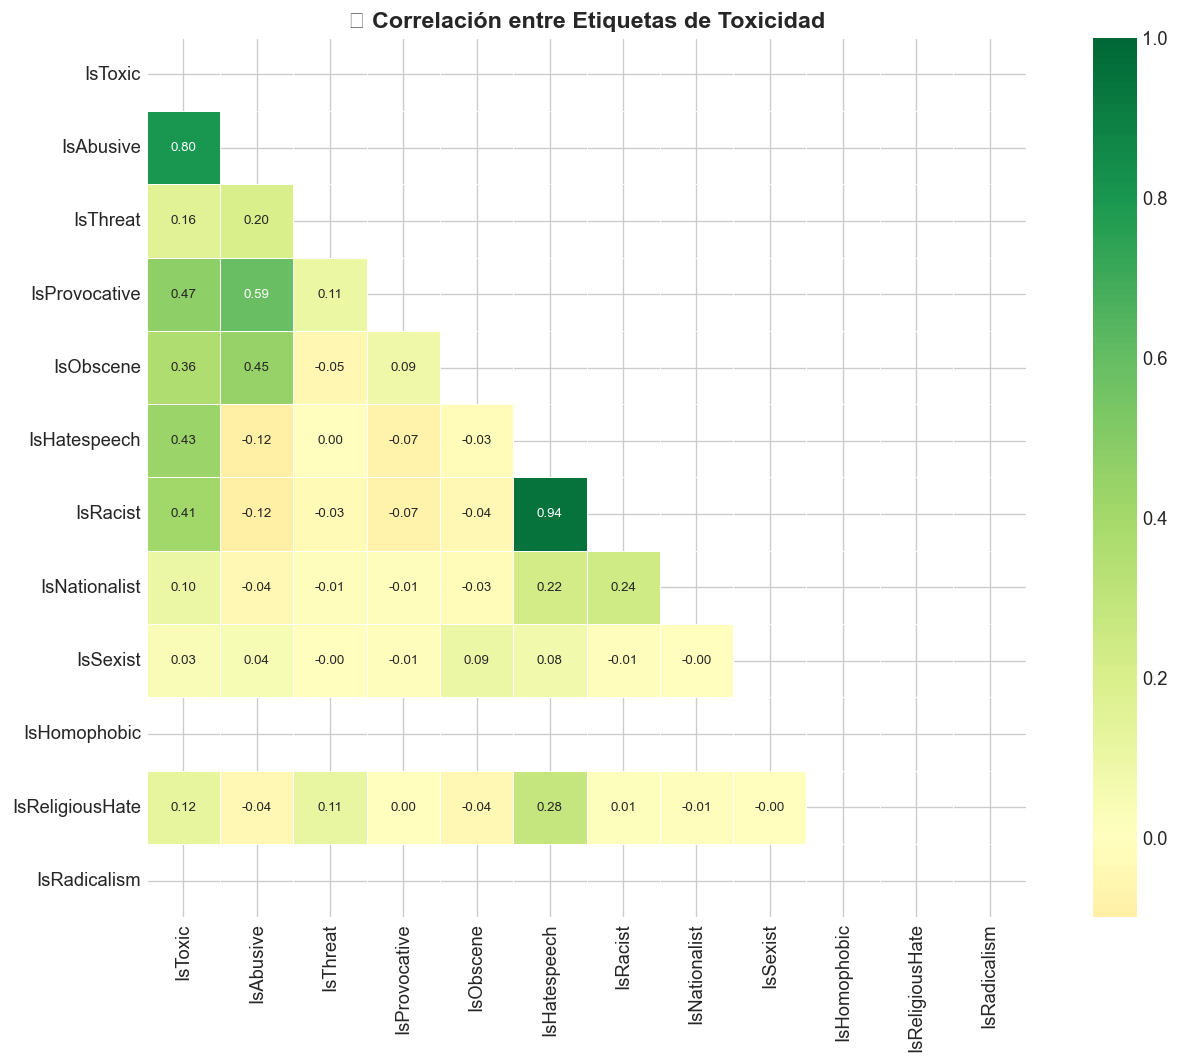

💾 Guardado: fig06_label_correlation.png


In [ ]:
# Heatmap de correlación entre etiquetas
label_cols = [
    'IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene',
    'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist',
    'IsHomophobic', 'IsReligiousHate', 'IsRadicalism'
]

# Convertir bool a int para correlación
corr = df[label_cols].astype(int).corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))  # triángulo superior
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-0.1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('🔗 Correlación entre Etiquetas de Toxicidad', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/fig06_label_correlation.png', bbox_inches='tight')
plt.show()
print('💾 Guardado: fig06_label_correlation.png')

=== 📊 Número de sub-etiquetas TRUE por comentario (solo tóxicos) ===
n_toxic_labels
1    100
2    291
3     47
4     15
5      6
Name: count, dtype: int64


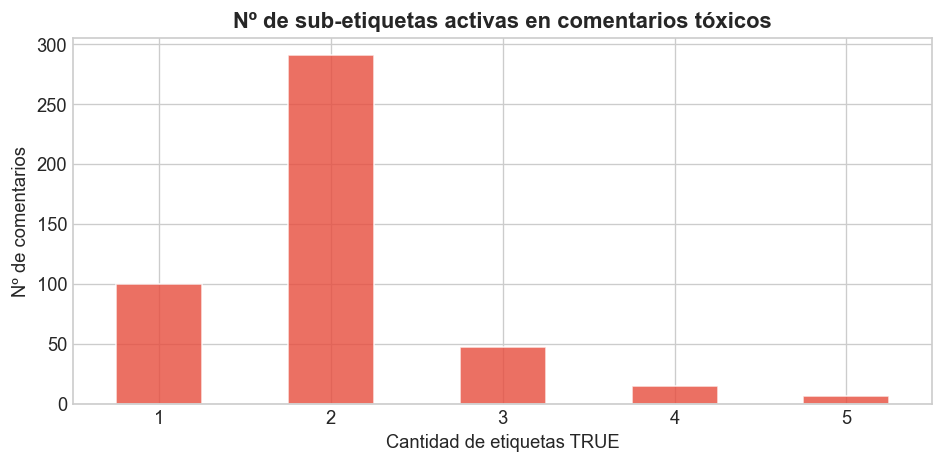

💾 Guardado: fig07_multilabel.png


In [ ]:
# ¿Cuántas etiquetas TRUE tiene cada comentario tóxico?
sub_label_cols = [
    'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene',
    'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist',
    'IsHomophobic', 'IsReligiousHate', 'IsRadicalism'
]
df['n_toxic_labels'] = df[sub_label_cols].astype(int).sum(axis=1)

print('=== 📊 Número de sub-etiquetas TRUE por comentario (solo tóxicos) ===')
print(df[df['IsToxic']]['n_toxic_labels'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 4))
df[df['IsToxic']]['n_toxic_labels'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color=PALETTE['toxic'], edgecolor='white', alpha=0.8
)
ax.set_title('Nº de sub-etiquetas activas en comentarios tóxicos', fontweight='bold')
ax.set_xlabel('Cantidad de etiquetas TRUE')
ax.set_ylabel('Nº de comentarios')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/fig07_multilabel.png', bbox_inches='tight')
plt.show()
print('💾 Guardado: fig07_multilabel.png')

### 💡 Insights — Correlación y Co-ocurrencia de Etiquetas
- **`IsRacist` ↔ `IsHatespeech`: correlación 0.94** — prácticamente perfecta, casi todo comentario racista es también hate speech. En modelado multi-etiqueta podrían tratarse como una sola categoría.
- **`IsAbusive` ↔ `IsToxic`: 0.80** — el abuso verbal es el componente dominante de la toxicidad en este dataset.
- **`IsAbusive` ↔ `IsProvocative`: 0.59** — la provocación y el abuso suelen ir de la mano.
- `IsHomophobic` e `IsRadicalism` aparecen completamente en blanco → 0 casos, confirma que deben eliminarse.
- El 64% de los comentarios tóxicos tienen **exactamente 2 sub-etiquetas activas** (la barra de 2 domina con ~290 casos), y solo ~100 tienen una sola → el odio raramente es "puro", casi siempre combina abuso + otra categoría.

## 10. 🔀 Solapamiento de Etiquetas (Análisis Multivariante)

=== 🔀 Solapamiento entre etiquetas (nº comentarios con ambas = TRUE) ===

                 IsAbusive  IsThreat  IsProvocative  IsObscene  IsHatespeech  \
IsAbusive            350.0      21.0          158.0      100.0          29.0   
IsThreat              21.0      21.0            9.0        0.0           3.0   
IsProvocative        158.0       9.0          158.0       26.0          13.0   
IsObscene            100.0       0.0           26.0      100.0          11.0   
IsHatespeech          29.0       3.0           13.0       11.0         138.0   
IsRacist              25.0       1.0           11.0        9.0         125.0   
IsNationalist          1.0       0.0            1.0        0.0           8.0   
IsSexist               1.0       0.0            0.0        1.0           1.0   
IsHomophobic           0.0       0.0            0.0        0.0           0.0   
IsReligiousHate        2.0       2.0            2.0        0.0          12.0   
IsRadicalism           0.0       0.0          

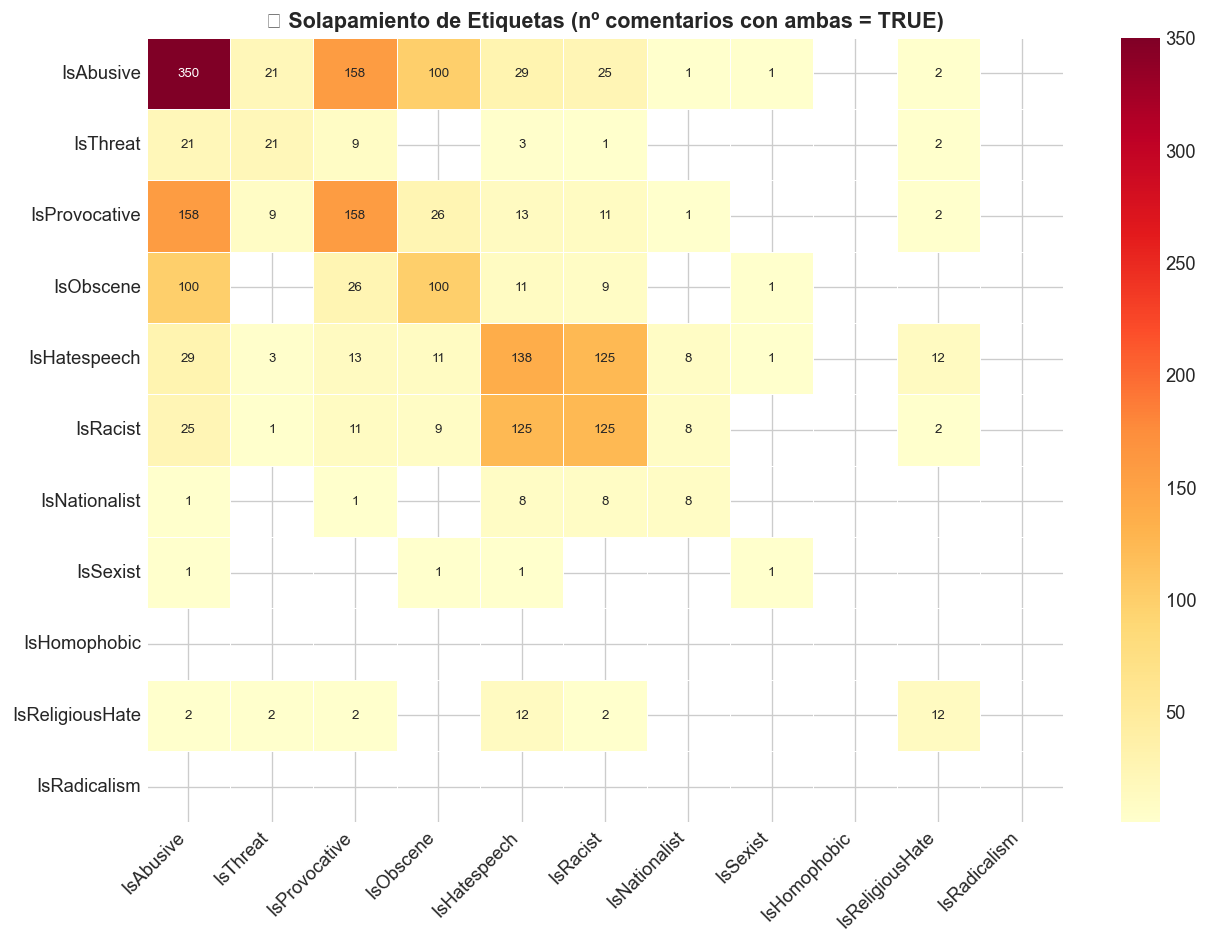

💾 Guardado: fig_overlap_heatmap.png


In [ ]:
sub_labels = ['IsAbusive','IsThreat','IsProvocative','IsObscene',
              'IsHatespeech','IsRacist','IsNationalist','IsSexist',
              'IsHomophobic','IsReligiousHate','IsRadicalism']

# --- Tabla de solapamiento numérico ---
print('=== 🔀 Solapamiento entre etiquetas (nº comentarios con ambas = TRUE) ===\n')
overlap_matrix = pd.DataFrame(index=sub_labels, columns=sub_labels, dtype=int)
for col_a in sub_labels:
    for col_b in sub_labels:
        overlap_matrix.loc[col_a, col_b] = int(
            ((df[col_a] == True) & (df[col_b] == True)).sum()
        )
print(overlap_matrix)

# --- Casos más destacados ---
print('\n=== 🔑 Solapamientos más relevantes ===')
for col_a in sub_labels:
    total_a = (df[col_a] == True).sum()
    if total_a == 0:
        continue
    for col_b in sub_labels:
        if col_a >= col_b:
            continue
        total_b = (df[col_b] == True).sum()
        if total_b == 0:
            continue
        overlap = int(((df[col_a] == True) & (df[col_b] == True)).sum())
        if overlap > 20:
            pct_a = overlap / total_a * 100
            pct_b = overlap / total_b * 100
            print(f'  {col_a} ∩ {col_b}: {overlap} casos ({pct_a:.0f}% de {col_a}, {pct_b:.0f}% de {col_b})')

# --- Heatmap de solapamiento ---
fig, ax = plt.subplots(figsize=(11, 8))
overlap_int = overlap_matrix.astype(int)
mask = overlap_int == 0
sns.heatmap(
    overlap_int, annot=True, fmt='d',
    cmap='YlOrRd', mask=mask,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('🔀 Solapamiento de Etiquetas (nº comentarios con ambas = TRUE)', fontweight='bold', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/fig_overlap_heatmap.png', bbox_inches='tight')
plt.show()
print('💾 Guardado: fig_overlap_heatmap.png')


### 💡 Insights — Solapamiento de Etiquetas
- **`IsRacist` ⊂ `IsHatespeech` al 100%**: los 125 comentarios racistas son también hate speech, y representan el 91% del hate speech total → son prácticamente la misma categoría en este dataset.
- **`IsAbusive` es el hub central**: solapa con `IsProvocative` (158 casos), `IsObscene` (100), `IsHatespeech` (29) y `IsRacist` (25) → el abuso verbal aparece combinado con casi todas las demás formas de odio.
- **`IsObscene` ∩ `IsProvocative`**: 26 casos, el 26% de los obscenos también son provocativos — lenguaje soez usado deliberadamente para provocar.
- `IsHomophobic` e `IsRadicalism` tienen **0 solapamientos con todo** → confirma su eliminación. `IsSexist` con solo 1 caso en toda la diagonal, igual.
- **Conclusión para el modelo**: dado el solapamiento masivo entre categorías, la clasificación **binaria `IsToxic`** es la estrategia correcta y más robusta para este dataset.

## 11. 🎬 Análisis por Vídeo

=== 🎬 Tasa de toxicidad por vídeo ===
    VideoId  total_comments  toxic_comments  toxic_rate
cT14IbTDW2c             143             105        73.4
04kJtp6pVXI             172             111        64.5
8HB18hZrhXc              38              23        60.5
Dt9-byUhPdg              34              17        50.0
dDbRyFIkNII              10               5        50.0
TZxEyoplYbI             104              50        48.1
bUgKZMSxr3E              39              18        46.2
5vF4si3hoRA               8               3        37.5
9pr1oE34bIM             274              88        32.1
     #NAME?              16               5        31.2
4rCweDxDqdw              37              10        27.0
XRuCW80L9mA              10               2        20.0
dG7mZQvaQDk             112              22        19.6


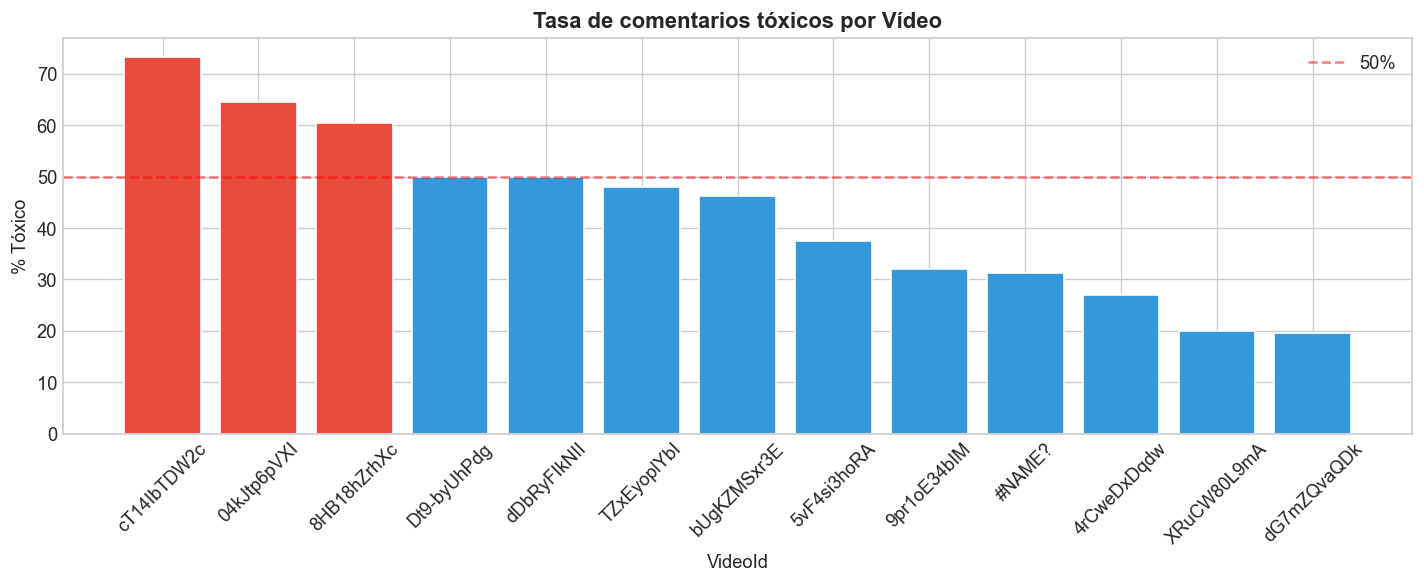

💾 Guardado: fig08_toxicity_by_video.png


In [ ]:
# Toxicidad por vídeo
video_stats = df.groupby('VideoId').agg(
    total_comments=('IsToxic', 'count'),
    toxic_comments=('IsToxic', 'sum'),
).reset_index()
video_stats['toxic_rate'] = (video_stats['toxic_comments'] / video_stats['total_comments'] * 100).round(1)
video_stats = video_stats.sort_values('toxic_rate', ascending=False)

print('=== 🎬 Tasa de toxicidad por vídeo ===')
print(video_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
colors_bar = [PALETTE['toxic'] if r > 50 else PALETTE['neutral'] for r in video_stats['toxic_rate']]
ax.bar(video_stats['VideoId'], video_stats['toxic_rate'], color=colors_bar, edgecolor='white')
ax.axhline(50, color='red', linestyle='--', alpha=0.5, label='50%')
ax.set_title('Tasa de comentarios tóxicos por Vídeo', fontweight='bold')
ax.set_xlabel('VideoId')
ax.set_ylabel('% Tóxico')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/fig08_toxicity_by_video.png', bbox_inches='tight')
plt.show()
print('💾 Guardado: fig08_toxicity_by_video.png')

### 💡 Insights — Toxicidad por Vídeo
- **3 vídeos superan el 50% de toxicidad** (`cT14IbTDW2c` 73%, `04kJtp6pVXI` 65%, `8HB18hZrhXc` 61%) → son vídeos sobre temas altamente polarizantes, probablemente los relacionados con Ferguson y el caso Brown.
- El vídeo `9pr1oE34bIM` tiene 274 comentarios (el 27% del dataset) pero solo un 32% de toxicidad → el volumen no implica más odio.
- `XRuCW80L9mA` y `dG7mZQvaQDk` tienen la tasa más baja (~20%) → contenido que genera debate más constructivo.
- **`#NAME?`** aparece con 31% de toxicidad — los 16 comentarios con VideoId corrupto tienen etiquetas válidas y se mantienen en el dataset.

## 12. 🧩 Patrones Especiales en el Texto

In [37]:
# Patrones a detectar con Regex (relevantes para el preprocesamiento)
patterns = {
    'URLs':              r'https?://\S+|www\.\S+',
    'Menciones (@)':     r'@\w+',
    'Hashtags (#)':      r'#\w+',
    'Números':           r'\b\d+\b',
    'Emojis/especiales': r'[^\x00-\x7F]+',
    'TODO MAYÚSCULAS':   r'\b[A-Z]{3,}\b',
    'Puntuación repetida': r'[!?]{2,}',
}

print('=== 🔍 Detección de patrones especiales ===\n')
print(f'  {"Patrón":<25} {"Total":>6} {"% Tóxico":>10} {"% NoTóxico":>12}')
print('  ' + '-'*55)

for name, pattern in patterns.items():
    mask = df['Text'].str.contains(pattern, regex=True, na=False)
    total = mask.sum()
    pct_toxic    = df[mask & (df['IsToxic'] == True)].shape[0] / max(total, 1) * 100
    pct_nontoxic = df[mask & (df['IsToxic'] == False)].shape[0] / max(total, 1) * 100
    print(f'  {name:<25} {total:>6} {pct_toxic:>9.1f}% {pct_nontoxic:>11.1f}%')

=== 🔍 Detección de patrones especiales ===

  Patrón                     Total   % Tóxico   % NoTóxico
  -------------------------------------------------------
  URLs                          12       8.3%        91.7%
  Menciones (@)                  5      60.0%        40.0%
  Hashtags (#)                   9      22.2%        77.8%
  Números                      132      34.1%        65.9%
  Emojis/especiales            203      44.8%        55.2%
  TODO MAYÚSCULAS              185      55.1%        44.9%
  Puntuación repetida           65      44.6%        55.4%


### 💡 Insights — Patrones Especiales (Regex)
- **URLs**: 91.7% pertenecen a comentarios NO tóxicos → confirma el hallazgo anterior, los links son señal de argumentación, no de odio.
- **TODO MAYÚSCULAS**: el patrón más discriminante con 55.1% tóxico vs 44.9% → escribir en mayúsculas es una señal moderada de agresividad.
- **Menciones (@)**: solo 5 casos pero el 60% son tóxicos → cuando alguien menciona directamente a otro usuario, suele ser para atacarle.
- **Emojis y puntuación repetida**: distribución casi 50/50 → no discriminan entre clases, pueden ignorarse como features.

## 13. 📋 Resumen de Hallazgos y Recomendaciones

print("""
╔══════════════════════════════════════════════════════════════════╗\n
║              📋 RESUMEN EDA — HALLAZGOS CLAVE                    ║\n
╠══════════════════════════════════════════════════════════════════╣\n
║                                                                  ║\n
║  DATASET                                                         ║\n
║  • 1.000 comentarios originales → 997 tras eliminar 3 duplicados ║\n
║  • 13 vídeos de YouTube | 15 columnas | 0 valores nulos          ║\n
║  • 16 filas con VideoId corrupto (#NAME?) → texto válido,        ║\n
║    se conservan (VideoId no se usará como feature)               ║\n
║                                                                  ║\n
║  BALANCE DE CLASES                                               ║\n
║  • 46.0% tóxicos (459) / 54.0% no tóxicos (538) → ratio 0.85   ║\n
║  • Sub-etiquetas: Abusive 35.1% > Provocative 15.8% >           ║\n
║    Hatespeech 13.8% > Racist 12.5% > Obscene 10.0%              ║\n
║  • IsHomophobic e IsRadicalism: 0 casos → eliminar              ║\n
║  • IsSexist: 1 caso (0.1%) → eliminar                           ║\n
║  • IsRacist ⊂ IsHatespeech al 100% → casi misma categoría       ║\n
║                                                                  ║\n
║  LONGITUD DE TEXTOS                                              ║\n
║  • Mediana 19 palabras / 102 chars | Máximo 815 palabras         ║\n
║  • Longitud NO discrimina toxicidad (190 vs 182 chars de media)  ║\n
║  • Tóxicos dominan textos cortos; no tóxicos los largos          ║\n
║  • Para LSTM/Transformers: max_len=200 cubre percentil 95+       ║\n
║                                                                  ║\n
║  VOCABULARIO                                                     ║\n
║  • Ambas clases comparten contexto (Ferguson, Brown, police)     ║\n
║  • El odio cambia el REGISTRO, no el TEMA                        ║\n
║  • Palabras más discriminantes: idiot(16x), bitch(14x),          ║\n
║    fuck(10x), bullshit(8x), isis(7x)                             ║\n
║  • URLs: 91.7% en no tóxicos → señal de argumentación           ║\n
║  • TODO MAYÚSCULAS: 55.1% tóxico → señal moderada de agresión   ║\n
║                                                                  ║\n
║  RECOMENDACIONES PARA PREPROCESAMIENTO                           ║\n
║  ✅ Eliminar URLs con regex (no aportan señal de odio)           ║\n
║  ✅ Lematización (spaCy) preferida sobre stemming                ║\n
║  ✅ Eliminar stopwords en inglés                                 ║\n
║  ✅ NO eliminar vocabulario de odio (idiot, bitch, isis...)      ║\n
║  ✅ Eliminar columnas: IsHomophobic, IsRadicalism, IsSexist      ║\n
║  ✅ Vectorización: TF-IDF con ngram_range=(1,2)                  ║\n
║  ✅ class_weight="balanced" como precaución en el modelo         ║\n
║                                                                  ║\n
║  MODELO SUGERIDO (baseline)                                      ║\n
║  → Clasificación BINARIA IsToxic (multi-etiqueta no viable)     ║\n
║  → Logistic Regression + TF-IDF (rápido, interpretable)         ║\n
║  → Luego: Random Forest / SVM / Ensemble + Optuna               ║\n
║  → Métrica principal: F1-score (no solo Accuracy)               ║\n
║                                                                  ║\n
╚══════════════════════════════════════════════════════════════════╝
""")


## 14. 💾 Exportar Dataset Enriquecido

In [ ]:
# Guardar versión enriquecida con features de EDA para reutilizar
df_export = df.copy()
df_export.to_csv('../data/processed/youtube_comments_eda_enriched.csv', index=False)
print('✅ Dataset con features de EDA exportado: youtube_comments_eda_enriched.csv')
print(f'   Columnas añadidas: char_count, word_count, sent_count, avg_word_len,')
print(f'                      has_url, has_mention, n_exclamation, n_question,')
print(f'                      pct_uppercase, n_toxic_labels')

print(f'\n📊 Resumen final del DataFrame:')
print(f'  Shape: {df_export.shape}')
print(f'  Columnas: {list(df_export.columns)}')

✅ Dataset con features de EDA exportado: youtube_comments_eda_enriched.csv
   Columnas añadidas: char_count, word_count, sent_count, avg_word_len,
                      has_url, has_mention, n_exclamation, n_question,
                      pct_uppercase, n_toxic_labels

📊 Resumen final del DataFrame:
  Shape: (997, 25)
  Columnas: ['CommentId', 'VideoId', 'Text', 'IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist', 'IsHomophobic', 'IsReligiousHate', 'IsRadicalism', 'char_count', 'word_count', 'sent_count', 'avg_word_len', 'has_url', 'has_mention', 'n_exclamation', 'n_question', 'pct_uppercase', 'n_toxic_labels']
